# 1. Quantum Phase Estimation: the theory

**Goal 1 of the project:** study the QPE protocol before implementing it.

This notebook derives QPE from scratch and reproduces the worked example from the
[PennyLane QPE tutorial](https://pennylane.ai/qml/demos/tutorial_qpe). The implementation
being exercised lives in [`src/qpe/`](../src/qpe/); here we care about *why it works*.

## The problem

Given a unitary $U$ and one of its eigenstates $|\psi\rangle$, we know that

$$U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle$$

for some phase $\theta \in [0, 1)$. Because $U$ is unitary the eigenvalue has modulus 1,
so *all* the information is in $\theta$. QPE estimates $\theta$.

This is not a curiosity. Eigenvalues are the answer to an enormous number of questions: molecular ground-state energies, the spectrum of a Hamiltonian, and (as we will see in
notebook 4) the inverse of a matrix. QPE is the primitive underneath all of them.

## Why we cannot just measure the phase

A global phase is unobservable. Measuring $|\psi\rangle$ after applying $U$ gives exactly
the same statistics as measuring $|\psi\rangle$, because the $e^{2\pi i\theta}$ factor cancels in
$|\langle x|\psi\rangle|^2$.

The trick is to make the phase *relative* rather than global, by putting a control qubit
in superposition. This is phase kickback, and it is the engine of the whole algorithm.

## Step 1: phase kickback

Take one control qubit in $|+\rangle = \tfrac{1}{\sqrt2}(|0\rangle + |1\rangle)$ and apply
a controlled-$U$ to $|\psi\rangle$:

$$\frac{1}{\sqrt2}\big(|0\rangle + |1\rangle\big)|\psi\rangle
\;\xrightarrow{\;cU\;}\;
\frac{1}{\sqrt2}\big(|0\rangle|\psi\rangle + |1\rangle\, e^{2\pi i\theta}|\psi\rangle\big)
= \frac{1}{\sqrt2}\big(|0\rangle + e^{2\pi i\theta}|1\rangle\big)\otimes|\psi\rangle.$$

Two things to notice:

1. The eigenstate $|\psi\rangle$ **factors out unchanged**: it is never disturbed, which
   is why the same $|\psi\rangle$ can be reused for every control qubit.
2. The phase has moved onto the *control*, where it is now a relative phase and therefore
   measurable.

Applying $U$ $k$ times multiplies the phase by $k$, since $U^k|\psi\rangle = e^{2\pi i k\theta}|\psi\rangle$:

$$\frac{1}{\sqrt2}\big(|0\rangle + e^{2\pi i \, k\theta}|1\rangle\big).$$

This is the lever. Using $k = 2^j$ on control qubit $j$ writes progressively more
significant bits of $\theta$ into the register.

## Step 2: the state before the inverse QFT

With $n$ control ("estimation") qubits, each in $|+\rangle$, and qubit $j$ controlling
$U^{2^j}$, the register ends up in

$$\frac{1}{\sqrt{2^n}}\bigotimes_{j=0}^{n-1}\Big(|0\rangle + e^{2\pi i\, 2^j \theta}|1\rangle\Big)
= \frac{1}{\sqrt{2^n}}\sum_{k=0}^{2^n-1} e^{2\pi i \theta k}\,|k\rangle .$$

The second form is worth staring at: expanding the product over all bit patterns
reassembles exactly the sum, because $\sum_j 2^j k_j = k$.

That sum is precisely the **Quantum Fourier Transform of the basis state**
$|2^n\theta\rangle$:

$$\mathrm{QFT}\,|y\rangle = \frac{1}{\sqrt{2^n}}\sum_{k=0}^{2^n-1} e^{2\pi i \, yk/2^n}|k\rangle .$$

Matching exponents gives $y = 2^n\theta$. So the controlled-$U$ ladder has left the
register holding the Fourier transform of the answer.

## Step 3: undo the transform

If the register holds $\mathrm{QFT}|2^n\theta\rangle$, then applying $\mathrm{QFT}^{-1}$
recovers $|2^n\theta\rangle$, and measuring in the computational basis reads off the
integer $m = 2^n\theta$, i.e.

$$\boxed{\;\theta = m/2^n\;}$$

**When $2^n\theta$ is an integer this is exact and deterministic**: the measurement returns $m$ with probability 1. That is the property the test suite is built on: it turns
"does QPE work?" into a hard assertion rather than a statistical one.

When $2^n\theta$ is *not* an integer, the inverse QFT cannot land on a single basis state
and instead produces a distribution peaked at the nearest representable values:

$$P(m) = \left|\frac{\sin\!\big(\pi 2^n (\theta - m/2^n)\big)}{2^n \sin\!\big(\pi(\theta - m/2^n)\big)}\right|^2 .$$

This is implemented as `expected_phase_distribution()` and we overlay it on simulation
below.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from qpe import qpe_circuit
from qpe.analysis import best_phase, expected_phase_distribution, plot_phase_distribution
from qpe.backends import run_circuit

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)
print("setup complete")

setup complete


## The circuit

`qpe_circuit()` assembles the three stages: Hadamards, the controlled-$U^{2^j}$ ladder,
and the inverse QFT.

Note that the controlled powers are built by *repeating* the gate rather than by
exponentiating the matrix. Both are correct; repetition keeps the exponential gate count
of QPE visible in the circuit, which is the honest picture of its cost, and it mirrors
the reference implementations.

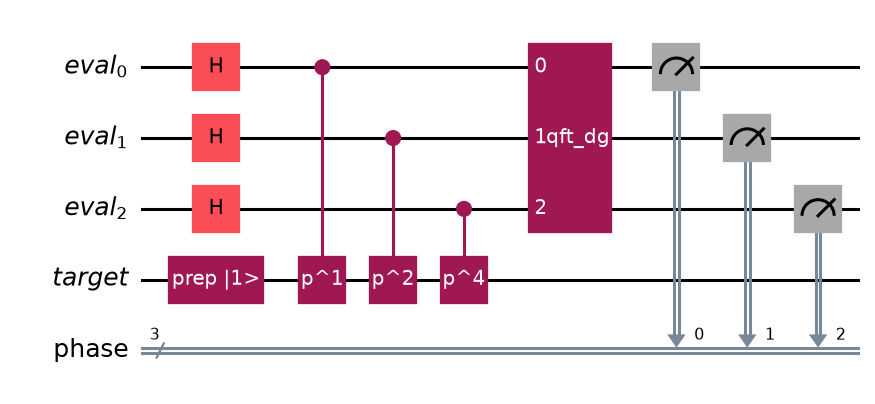

In [2]:
from qiskit.circuit.library import PhaseGate
from qiskit import QuantumCircuit

# |1> is an eigenstate of the phase gate P(phi), with eigenvalue e^{i phi}.
prep = QuantumCircuit(1, name="prep |1>")
prep.x(0)

demo = qpe_circuit(PhaseGate(2 * np.pi * 0.25), num_eval_qubits=3, state_prep=prep)
demo.draw("mpl", fold=-1)

## A case where the answer is exact

$\theta = 1/8$ needs 3 bits: $1/8 = 0.001_2$. With $n = 3$ estimation qubits, $2^n\theta = 1$
is an integer, so QPE must return $\theta = 1/8$ with certainty.

true phase      : 0.125
estimated phase : 0.125
probability     : 1.0000
error           : 0.00e+00


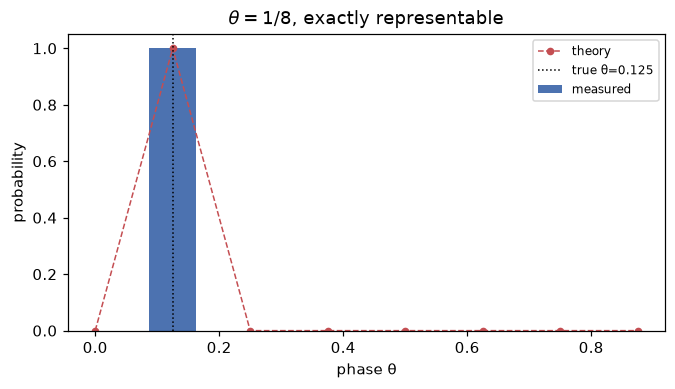

In [3]:
theta = 1/8
circuit = qpe_circuit(PhaseGate(2 * np.pi * theta), num_eval_qubits=3, state_prep=prep)
estimate = best_phase(run_circuit(circuit, "aer", shots=8192), num_eval_qubits=3)

print(f"true phase      : {theta}")
print(f"estimated phase : {estimate.phase}")
print(f"probability     : {estimate.probability:.4f}")
print(f"error           : {estimate.error_vs(theta):.2e}")

plot_phase_distribution(estimate, true_phase=theta, title=r"$\theta = 1/8$, exactly representable")
plt.show()

All the probability sits on one outcome. This is the ideal case, and it is worth
being explicit about *why* it happens: $1/8$ terminates in binary within 3 bits, so the
inverse QFT maps the register onto a single basis state with no leakage.

## Reproducing the PennyLane tutorial's example

The tutorial uses $U = R_\phi(2\pi/5)$, i.e. $\theta = 0.2$, with 4 estimation qubits, and
observes a peak at $0.0011_2 = 0.1875$.

$0.2$ is *not* dyadic: in binary it is $0.001100110011\ldots$, repeating forever, so no finite register can represent it. The best a 4-bit register can do is $3/16 = 0.1875$.

true phase        : 0.2
most likely       : 0.1875  =  0011_2
probability       : 0.8744
resolution (2^-n) : 0.0625
error             : 0.0125

PennyLane's tutorial reports a peak at 0.0011_2 = 0.1875: matched.


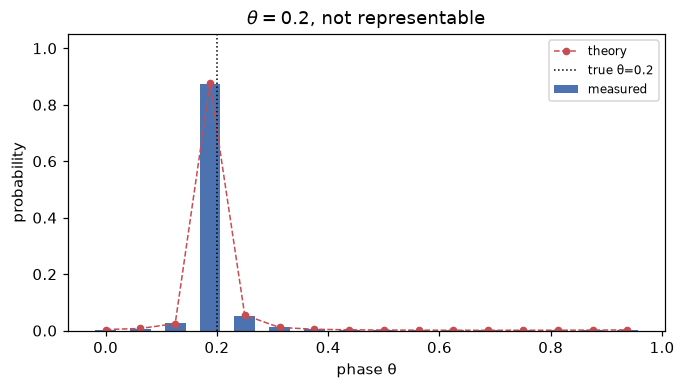

In [4]:
theta = 0.2
n = 4
circuit = qpe_circuit(PhaseGate(2 * np.pi * theta), num_eval_qubits=n, state_prep=prep)
estimate = best_phase(run_circuit(circuit, "aer", shots=8192), num_eval_qubits=n)

print(f"true phase        : {theta}")
print(f"most likely       : {estimate.phase}  =  {int(estimate.phase * 2**n):0{n}b}_2")
print(f"probability       : {estimate.probability:.4f}")
print(f"resolution (2^-n) : {estimate.resolution}")
print(f"error             : {estimate.error_vs(theta):.4f}")
print()
print("PennyLane's tutorial reports a peak at 0.0011_2 = 0.1875: matched.")

plot_phase_distribution(estimate, true_phase=theta, title=r"$\theta = 0.2$, not representable")
plt.show()

The distribution is peaked but no longer a delta: the amplitude spreads over
neighbouring values, with a long, rapidly decaying tail. The red curve is the closed-form
expression from Step 3, and it lies on top of the sampled histogram, confirming that the
implementation reproduces the theory quantitatively rather than just qualitatively.

Note also that the *second* most likely outcome is $0.25 = 0.0100_2$, the other neighbour
of $0.2$. The distribution is asymmetric because $0.2$ sits closer to $0.1875$ than to
$0.25$.

## Precision: what more qubits buy

Each additional estimation qubit halves the resolution $2^{-n}$, so error falls
*exponentially* in $n$. But qubit $j$ applies $U$ $2^j$ times, so the gate count also
grows exponentially, and the total cost is $O(2^n) = O(1/\varepsilon)$ for target error
$\varepsilon$.

This is the central trade-off of QPE, and the reason "just add more qubits" is not free.

In [5]:
theta = 0.2
rows = []
for n in range(2, 9):
    circuit = qpe_circuit(PhaseGate(2 * np.pi * theta), num_eval_qubits=n, state_prep=prep)
    est = best_phase(run_circuit(circuit, "aer", shots=4096), num_eval_qubits=n)
    rows.append((n, est.phase, est.error_vs(theta), est.probability, circuit.depth()))

print(f"{'n':>2} {'estimate':>10} {'error':>10} {'P(peak)':>9} {'depth':>7}")
print("-" * 44)
for n, ph, err, p, d in rows:
    print(f"{n:>2} {ph:>10.5f} {err:>10.5f} {p:>9.3f} {d:>7}")

 n   estimate      error   P(peak)   depth
--------------------------------------------
 2    0.25000    0.05000     0.882       5
 3    0.25000    0.05000     0.571       6
 4    0.18750    0.01250     0.881       7
 5    0.18750    0.01250     0.594       8
 6    0.20312    0.00312     0.879       9
 7    0.20312    0.00312     0.567      10
 8    0.19922    0.00078     0.866      11


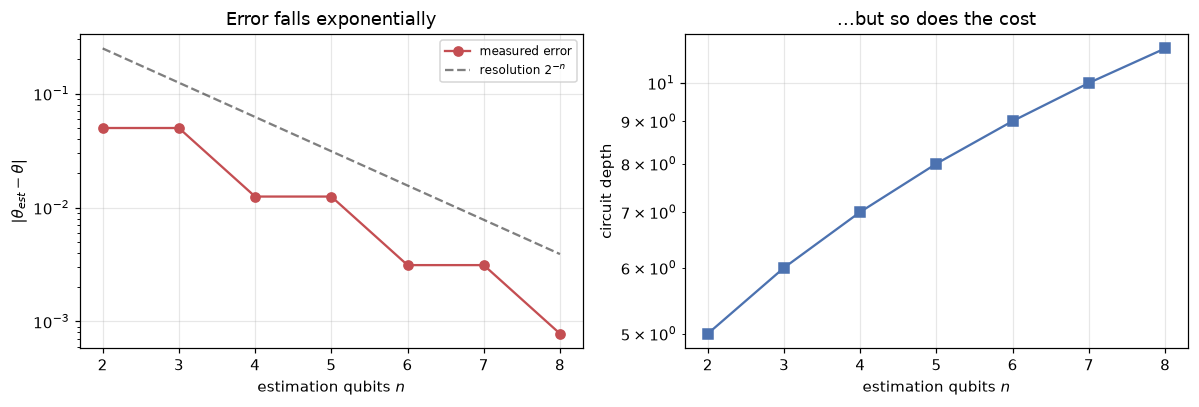

In [6]:
ns = [r[0] for r in rows]
errors = [r[2] for r in rows]
depths = [r[4] for r in rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.semilogy(ns, errors, "o-", color="#C44E52", label="measured error")
ax1.semilogy(ns, [2.0**-n for n in ns], "k--", alpha=0.5, label=r"resolution $2^{-n}$")
ax1.set_xlabel("estimation qubits $n$"); ax1.set_ylabel(r"$|\theta_{est} - \theta|$")
ax1.set_title("Error falls exponentially"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.semilogy(ns, depths, "s-", color="#4C72B0")
ax2.set_xlabel("estimation qubits $n$"); ax2.set_ylabel("circuit depth")
ax2.set_title("...but so does the cost"); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

The error tracks the resolution line closely, and the depth climbs just as fast.
Buying one more bit of precision doubles the work, which is exactly why the hardware
experiments in notebook 3 keep $n$ small.

## What if the input is not an eigenstate?

Nothing in the derivation required $|\psi\rangle$ to be an eigenstate; it only required
linearity. Writing an arbitrary input in the eigenbasis, $|\phi\rangle = \sum_i c_i|u_i\rangle$,
QPE produces

$$\sum_i c_i\, |\widetilde{\theta_i}\rangle \otimes |u_i\rangle,$$

so measuring the estimation register samples eigenphase $\theta_i$ with probability
$|c_i|^2$, and **collapses the target register onto the corresponding eigenstate**.

This is genuinely useful: it samples the spectrum without diagonalising anything. It is
also precisely the mechanism HHL exploits in notebook 4, where $|b\rangle$ is deliberately
*not* an eigenvector of $A$.

  phase 0.000  ->  probability 0.4973
  phase 0.250  ->  probability 0.5027


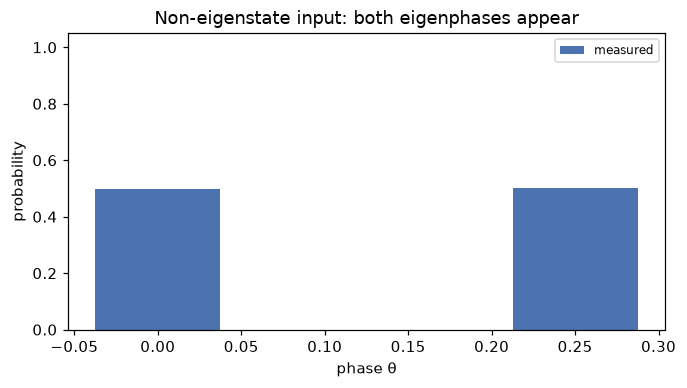

In [7]:
# For a phase gate: |0> has phase 0, |1> has phase theta.
# An equal superposition should therefore yield both, with equal weight.
theta = 0.25
superposition = QuantumCircuit(1, name="prep |+>")
superposition.h(0)

circuit = qpe_circuit(PhaseGate(2 * np.pi * theta), num_eval_qubits=3, state_prep=superposition)
est = best_phase(run_circuit(circuit, "aer", shots=8192), num_eval_qubits=3)

for phase, prob in sorted(est.distribution.items()):
    if prob > 0.01:
        print(f"  phase {phase:.3f}  ->  probability {prob:.4f}")

plot_phase_distribution(est, title="Non-eigenstate input: both eigenphases appear")
plt.show()

Both eigenphases appear with weight $\approx 0.5$, matching $|c_i|^2$ for an equal
superposition.

## Summary

| | |
|---|---|
| **What QPE does** | estimates $\theta$ where $U\lvert\psi\rangle = e^{2\pi i\theta}\lvert\psi\rangle$ |
| **How** | phase kickback writes $\theta$ into a register as a QFT; the inverse QFT reads it out |
| **Exact when** | $2^n\theta$ is an integer; then the result is deterministic |
| **Otherwise** | a distribution peaked at the nearest representable value |
| **Cost** | error $\varepsilon$ requires $O(1/\varepsilon)$ applications of $U$ |
| **Non-eigenstates** | sample eigenphases with probability $\lvert c_i\rvert^2$ |

Next: [`02_qpe_qiskit.ipynb`](02_qpe_qiskit.ipynb) validates the implementation against
known eigenvalues in detail.